In this case we grab a continium of values for $\Delta_q$ to extract maps of population and spectral area ratios wrt $\Delta_q$ and $\omega_{THz}$
IDEA:

1. Populations
    - map of $P(\omega_b,\Delta_q )$ analytical
    - map of $P(\omega_b,\Delta_q )$ numerical
    - one of those + contour lines
2. Ratios
    - map of $\frac{A_d}{A_i}(\omega_b,\Delta_q )$ analytical
    - map of $\frac{A_d}{A_i}(\omega_b,\Delta_q )$ numerical
    - one of those + contour lines

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from matplotlib import rc

# Font and LaTeX config (para las gráficas, que queden estilo 'paper')
rc('font', **{'family': 'serif', 'serif': ['Helvetica']})
rc('text', usetex=True)



Parameters

In [2]:
kappa_b = 1 #decay en la cav de THz
gamma = 1e-4 * kappa_b # decay en el qubit

chi =  0.1*kappa_b      # acoplo qubit con THz

Omega = 200 * kappa_b  # en uds de kappa_b y 1e6 veces mayor que gamma

Nb = 3         # segunda cavidad

npoints = 99

# eje horizontal (frecuencia espectral)
w_THz_list = np.linspace(0, 400, npoints)
# eje vertical (detuning del qubit)
Delta_q_list = np.linspace(0, 1.1*Omega, npoints)
# rango para calcular el área del espectro
Delta_a_list = np.linspace(-3*Omega, 3*Omega, npoints)


x_axis = (w_THz_list - Omega* np.ones(len(w_THz_list)))/gamma
y_axis = Delta_q_list/Omega

Operators

In [3]:
sx = tensor(sigmax(), qeye(Nb))
sz = tensor(sigmaz(), qeye(Nb))
sm = tensor(sigmam(), qeye(Nb))

b = tensor(qeye(2), destroy(Nb))
b_dag = b.dag()

# Disipadores
D_with = [
    np.sqrt(gamma) * sm,
    np.sqrt(kappa_b) * b
]

num_Pplus_matrix = np.zeros((len(Delta_q_list),len(w_THz_list)))

# 1.1: Map of analytical $\ket{+}$ population


For a given $\Delta_q$:

\begin{equation}
\Omega_R = 2\sqrt{\Delta_q ^2 + \frac{\Omega^2}{4} }, \ h = \frac{\Omega_R - 2\Delta_q}{\Omega}\longrightarrow \theta\equiv arctan(h), \theta\in[0,\pi/4]
\end{equation}

The popualtion reads
$$ \langle \xi^\dagger \xi \rangle  = \frac{\gamma\sin^4\theta}{\gamma\sin^4\theta + \gamma\cos^4\theta + \Gamma_P}$$

where $\Gamma_P$ is the Purcell factor, given by: $\Gamma_P = \frac{g^2\gamma}{(\omega_b-\Omega)^2+\gamma^2/4}$, with $g=2\chi\cos\theta\sin\theta$.

In [4]:
# Aquí hacemos el cálculo analítico y lo guardamos

#matriz en la que irá almacenada la información en este $\Delta_q$ 
P_an_map = np.zeros((len(Delta_q_list), len(w_THz_list)))


for i, Delta_q in enumerate(Delta_q_list):

    #parámetros necesarios de cada Delta_q
    Omega_R = 2*np.sqrt(Delta_q**2+Omega**2/4)
    h = (Omega_R - 2*Delta_q)/Omega
    theta = np.arctan(h)

    cos = np.cos(theta)
    sin = np.sin(theta)
    g_eff = 2*chi*sin*cos # acoplo efectivo
    
    pump =  gamma* sin**4
    decay = gamma * cos**4
    
    for j, w_b in enumerate(w_THz_list):
        Purcell = g_eff**2*kappa_b / ( (w_b-Omega_R)**2 + kappa_b**2/4 ) 
        P_an_map[i,j] = pump/(pump + decay + Purcell) # (quiero que la coord x sea omega_b)



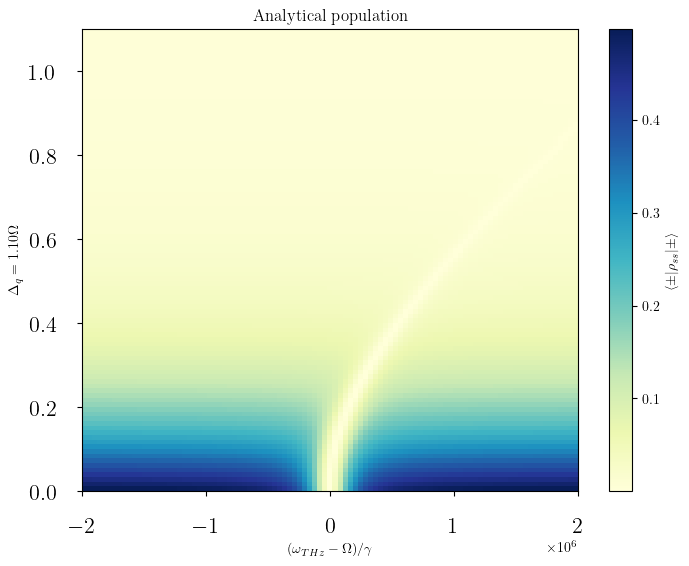

In [5]:
# Crear figuras y ejes
fig, ax = plt.subplots(figsize=(8, 6))


# ------------------------
im = ax.imshow(
    P_an_map,
    extent=[x_axis[0], x_axis[-1],
            y_axis[0], y_axis[-1]],
    aspect='auto',
    origin='lower',
    cmap='YlGnBu'
)

ax.set_xlabel(r"$(\omega_{THz}-\Omega)/\gamma$")
ax.set_ylabel(rf"$\Delta_q = {Delta_q/Omega:.2f}\Omega$")
ax.set_title(r"Analytical population")
ax.tick_params(labelsize=16, pad=15)
fig.colorbar(im, ax=ax, label=r"$\langle \pm | \rho_{ss} | \pm \rangle$")


# 1.2: Map of numerical population
(calculate from steady state... etc)

In [6]:
#matriz en la que irá almacenada la información en este $\Delta_q$ 
P_num_map = np.zeros((len(Delta_q_list), len(w_THz_list)))

for i, Delta_q in enumerate(Delta_q_list):

    # vectors where we store the population @ each w_b
    pops_plus = []

    for j, w_b in enumerate(w_THz_list):

        H_qubit = (Omega/2)*sigmax() + Delta_q*sigmaz()
        eigvals, eigstates = H_qubit.eigenstates()

        plus_state = eigstates[1]  # mayor energía
        minus_state = eigstates[0] #menor energía

        # extender al espacio total
        plus = tensor(eigstates[1], qeye(Nb))
        P_plus = plus * plus.dag()

        minus = tensor(eigstates[0], qeye(Nb))
        P_minus = minus * minus.dag()

        H = (Omega/2)*sx + Delta_q * sz + w_b * b_dag * b + chi * (sz + 1) * (b + b_dag)

        rho_ss_with = steadystate(H, D_with)
        pop_plus= expect(P_plus, rho_ss_with)

        P_num_map[i,j] = pop_plus

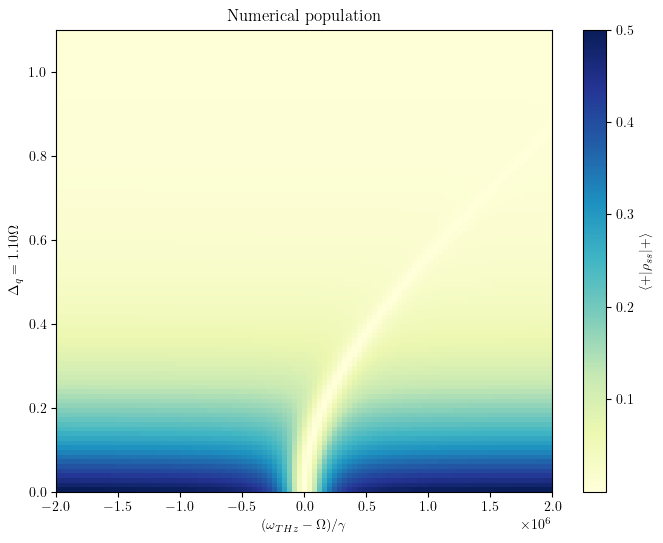

In [7]:
# Crear figuras y ejes
fig, ax = plt.subplots(figsize=(8, 6))


# ------------------------
im = ax.imshow(
    P_num_map,
    extent=[x_axis[0], x_axis[-1],
            y_axis[0], y_axis[-1]],
    aspect='auto',
    origin='lower',
    cmap='YlGnBu'
)

ax.set_xlabel(r"$(\omega_{THz}-\Omega)/\gamma$")
ax.set_ylabel(rf"$\Delta_q = {Delta_q/Omega:.2f}\Omega$")
ax.set_title(r"Numerical population")
fig.colorbar(im, ax=ax, label=r"$\langle + | \rho_{ss} | + \rangle$")

### 1.3: Comparision of analytical and numerical
Create a map whit countour lines for both cases

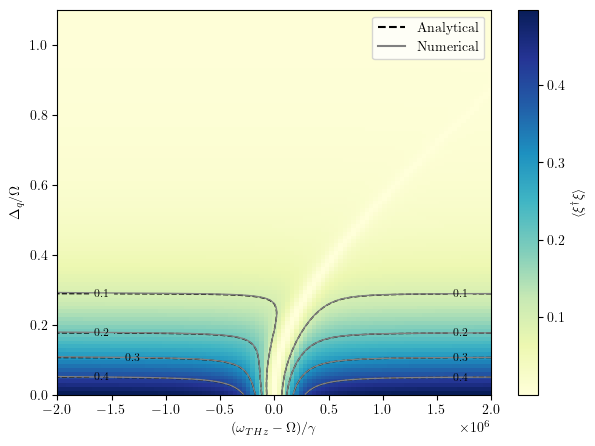

In [8]:
fig, ax = plt.subplots(figsize=(7,5))

# mapa de fondo (analítico)
im = ax.imshow(
    P_an_map,
    origin='lower',
    aspect='auto',
    extent=[
        x_axis[0], x_axis[-1],
        y_axis[0], y_axis[-1]
    ],
    cmap='YlGnBu'
)

fig.colorbar(im, ax=ax, label=r'$\langle \xi^\dagger \xi \rangle$')


# mismos niveles para ambos
levels = np.linspace(0, 1, 11)

# contornos analíticos
cs_an = ax.contour(
    x_axis,
    y_axis,
    P_an_map,
    levels=levels,
    colors='black',
    linestyles='dashed',
    linewidths=1
)

# etiquetas SOLO aquí
ax.clabel(cs_an, inline=True, fontsize=8)


# contornos numéricos
cs_num = ax.contour(
    x_axis,
    y_axis,
    P_num_map,
    levels=levels,
    colors='gray',
    linewidths=1
)


# leyenda manual
from matplotlib.lines import Line2D

legend_lines = [
    Line2D([0], [0], color='black', linestyle = 'dashed' ,label='Analytical'),
    Line2D([0], [0], color='gray',  label='Numerical')
]

ax.legend(handles=legend_lines)


ax.set_xlabel(r"$(\omega_{THz}-\Omega)/\gamma$")
ax.set_ylabel(r'$\Delta_q/\Omega$')
plt.show()

# 2.1: Analytical map of spectral peak ratio

Hypothesis for the analytical result is that the areas under left and right peak are related by the expression:

\begin{equation}
\frac{A_{right}}{A_{left}} = \frac{\sin^4\theta  P_+}{\cos^4\theta(1-P_+)}
\end{equation}
where $P_+$ represents the population of $\ket{+}$ at the steady state, recently calculated.


In [9]:
#~mapa que almacena el ratio para este caso
S_an_map =  np.zeros((len(Delta_q_list), len(w_THz_list)))

for i, Delta_q in enumerate(Delta_q_list):
    #parámetros necesarios de cada Delta_q
    Omega_R = 2*np.sqrt(Delta_q**2+Omega**2/4)
    h = (Omega_R - 2*Delta_q)/Omega
    theta = np.arctan(h)

    cos = np.cos(theta)
    sin = np.sin(theta)
    
    for j, w_b in enumerate(w_THz_list):
        S_an_map[i,j] = sin**4 * P_an_map[i,j] / (cos**4 * (1-P_an_map[i,j]))

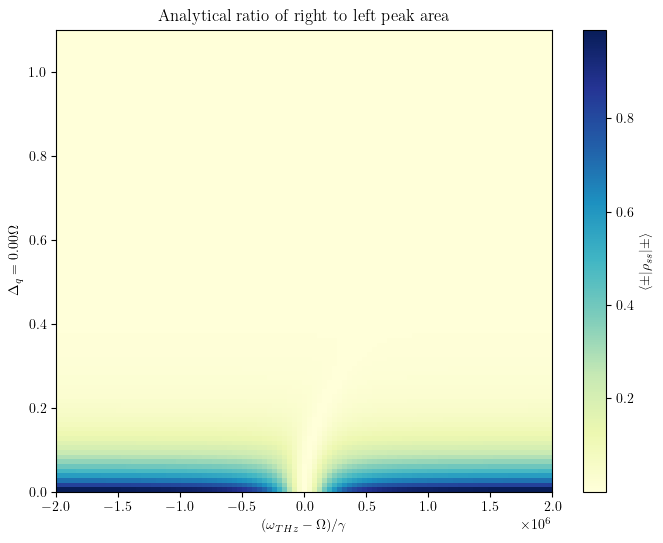

In [14]:
# Crear figuras y ejes
fig, ax = plt.subplots(figsize=(8, 6))


# ------------------------
im = ax.imshow(
    S_an_map,
    extent=[x_axis[0], x_axis[-1],
            y_axis[0], y_axis[-1]],
    aspect='auto',
    origin='lower',
    cmap='YlGnBu'
)

ax.set_xlabel(r"$(\omega_{THz}-\Omega)/\gamma$")
ax.set_ylabel(rf"$\Delta_q = {Delta_q/Omega:.2f}\Omega$")
ax.set_title(r'Analytical ratio of right to left peak area')
fig.colorbar(im, ax=ax, label=r"$\langle \pm | \rho_{ss} | \pm \rangle$")

# 2.2 Numerical map of spectral peak ratio
First of all, in order to compute this calculation, an expansion of the Hilbert space is needed.
This is done in order to accomodate the participation of a very weakly interacting optical cavity that will serve as a sensor, serving as a method to calculate the spectrum

In [11]:
kappa_a = 1 # decay en el sensor (debe ser pequeño, pero mayor que g)
g = 0.001       # acoplo qubit con el sensor
Na = 2        # truncación de la primera cavidad 


# Operadores en el espacio producto tensorial
sx = tensor( sigmax(), qeye(Na), qeye(Nb))
sp = tensor( sigmap(), qeye(Na), qeye(Nb))
sm = tensor( sigmam(), qeye(Na), qeye(Nb))
sz = tensor( sigmaz(), qeye(Na), qeye(Nb))

a = tensor( qeye(2), destroy(Na) , qeye(Nb))
a_plus = a.dag()

b = tensor( qeye(2), qeye(Na), destroy(Nb))
b_plus = b.dag()

# Disipadores
Dissipators = []

Dissipators.append(np.sqrt(gamma) * sm)
Dissipators.append(np.sqrt(kappa_a) * a)
Dissipators.append(np.sqrt(kappa_b) * b)

Omega_R = 2*np.sqrt(Delta_q**2+(Omega/2)**2)

State the fit of spectrum = sum of 3 lorentizians

In [12]:
npoints = 49

# eje horizontal (frecuencia espectral)
w_THz_list = np.linspace(0, 400, npoints)
# eje vertical (detuning del qubit)
Delta_q_list = np.linspace(0, 1.1*Omega, npoints)
# rango para calcular el área del espectro
Delta_a_list = np.linspace(-3*Omega, 3*Omega, npoints)


x_axis = (w_THz_list - Omega* np.ones(len(w_THz_list)))/gamma
y_axis = Delta_q_list/Omega

# rango completo del Mollow
Delta_a_list = np.linspace(-1.5*Omega_R, 1.5*Omega_R, 49)
 

def lorentzian(x, A, x0, gamma):
    return A * gamma**2 / ((x - x0)**2 + gamma**2)

def mollow_spectrum(x,
                    A0, x0, gamma0,
                    A_L, xL, gammaL,
                    A_R, xR, gammaR,
                    C):
    
    central = lorentzian(x, A0, x0, gamma0)
    left = lorentzian(x, A_L, xL, gammaL)
    right = lorentzian(x, A_R, xR, gammaR)

    return central + left + right + C




In [ ]:
#~mapa que almacena el ratio para este caso
S_num_map =  np.zeros((len(Delta_q_list), len(w_THz_list)))

H0 =  (Omega/2) * sx \
                + g * (a_plus * sm + a * sp) + chi * (sz+ 1)*(b_plus + b) 

for i, Delta_q in enumerate(Delta_q_list):

    H1 = H0 + Delta_q * sz

    for j, w_b in enumerate(w_THz_list):

        H2 = H1 + w_b * b_plus * b

        spectrum = []

        for Delta_a in Delta_a_list:
            H = H2 + Delta_a * a_plus * a
            rho_SS = steadystate(H, Dissipators)
            spectrum.append(expect(a_plus * a, rho_SS))

        spectrum = np.array(spectrum)


        # -------------------------
        # guesses iniciales
        # -------------------------

        C0 = np.min(spectrum)

        # pico central
        A0 = np.max(spectrum) - C0
        x0 = Delta_a_list[np.argmax(spectrum)]
        gamma0 = Omega_R/10

        # picos laterales
        xL = -Omega_R
        xR = Omega_R

        AL = A0/3
        AR = A0/3

        gammaL = Omega_R/10
        gammaR = Omega_R/10


        p0 = [
            A0, x0, gamma0,
            AL, xL, gammaL,
            AR, xR, gammaR,
            C0
        ]


    
        popt, pcov = curve_fit(
            mollow_spectrum,
            Delta_a,
            spectrum,
            p0=p0,
            maxfev=50000
        )


        (
        A0_fit, x0_fit, gamma0_fit,
        AL_fit, xL_fit, gammaL_fit,
        AR_fit, xR_fit, gammaR_fit,
        C_fit
        ) = popt


        # áreas de cada Lorentziana
        area_L = np.pi * AL_fit * np.abs(gammaL_fit)
        area_R = np.pi * AR_fit * np.abs(gammaR_fit)
        area_0 = np.pi * A0_fit * np.abs(gamma0_fit)

        ratio = area_R/area_L

        S_num_map[i,j] = ratio



KeyboardInterrupt: 

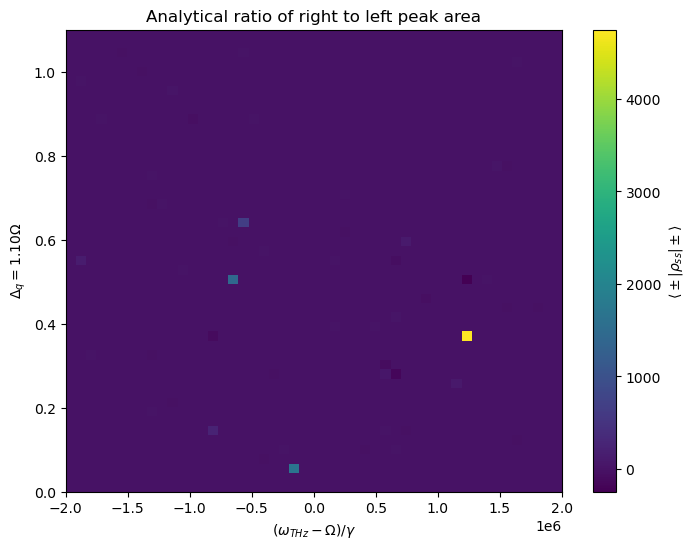

In [ ]:
# Crear figuras y ejes
fig, ax = plt.subplots(figsize=(8, 6))


# ------------------------
im = ax.imshow(
    S_num_map,
    extent=[x_axis[0], x_axis[-1],
            y_axis[0], y_axis[-1]],
    aspect='auto',
    origin='lower'
)

ax.set_xlabel(r"$(\omega_{THz}-\Omega)/\gamma$")
ax.set_ylabel(rf"$\Delta_q = {Delta_q/Omega:.2f}\Omega$")
ax.set_title(r'Numerical ratio of right to left peak area')
fig.colorbar(im, ax=ax, label=r"$\langle \pm | \rho_{ss} | \pm \rangle$")